In [1]:
import tensorflow as tf 
import numpy as np
gpus = tf.config.list_physical_devices("GPU")

print(gpus)

import import_data

2025-04-11 21:01:10.338350: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-11 21:01:10.371393: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-11 21:01:10.371419: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-11 21:01:10.372600: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-11 21:01:10.379148: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
data ['Simulation_01_210209_001_002', 'LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_201223_001_002', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'RA_RAA_141230', 'Simulation_01_200316_001_  1', 'TwoRotors_181219', 'RA_RAFW_SAF_140730', 'Simulation_01_200212_001_  4']

Egms models LOADED - var: **egms_all_models**, **egms_values** 
EGMS data normalized - var: **egms_filtered_norm** 
Transfer matrices LOADED - var: **transfer_matrices** 
BSPS Models LOADED - var: **bsps_all_models** 
BSPS 64 Models LOADED - var: **bsps_64_all_models** 


In [2]:
egms_all_models = import_data.egms_all_models
egms_values = import_data.egms_values
egms_filtered_norm = import_data.egms_filtered_norm
bsps_all_models = import_data.bsps_all_models
bsps_64_all_models = import_data.bsps_64_all_models
transfer_matrices = import_data.transfer_matrices

In [5]:
import sys, os


from scipy.io import loadmat
import numpy as np
from random import randint
import matplotlib.pyplot as plt
from itertools import product
from numpy.random import default_rng
import scipy.io
import h5py
from scipy import signal as sigproc
from scipy.interpolate import interp1d
from math import floor
from scipy import signal
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import tensorflow as tf
import random
import math
from sklearn.metrics import mean_squared_error
from fastdtw import fastdtw
import time
import keras
from keras import models, layers
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from tensorflow.keras import datasets, layers, models, losses, Model
from generators import *
from numpy import reshape
import matplotlib.image
from scipy.io import savemat
#from plots import *
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from datetime import time


Uso un bsps_64 rel con el modelo 0 para aplicarle wavelet scattering, sacar los coefficientes de diferente orden (0, 1 o 2) y dibujar esos coefficientes dependiendo de su orden. 

Que uso tienen y que representan los coeffs de distinto orden: 

* 0: Coeficiente de orden cero (energía total de la señal).
* 1: Coeficiente de primer orden (captura variaciones locales).
* 2: Coeficiente de segundo orden (captura interacciones entre diferentes escalas).

In [6]:
import kymatio
from kymatio import Scattering1D

signal_ex = bsps_64_all_models[0][0,:]
T = len(signal_ex)


scattering = Scattering1D(J=6, shape=T, Q=8) #calculate wavelet scattering coeffs

# Perform the scattering transform
Sx = scattering(signal_ex)
meta = scattering.meta()

# Metadata
print("meta keys", meta.keys())  

# Explorar los órdenes de los coeficientes
print('order of coeffs', meta['order'])  # coeff order

order_0_coeffs = Sx[meta['order'] == 0]  # coeffs order 0
print("Coeffs order 0:", order_0_coeffs.shape)

order_1_coeffs = Sx[meta['order'] == 1] # coeffs order 1
print("Coeffs order 1:", order_1_coeffs.shape)

order_2_coeffs = Sx[meta['order'] == 2] # coeffs order 2
print("Coeffs order 2:", order_2_coeffs.shape)

#------------------------------------------------------------------------------------------------------
#no entiendo bien que es 23 en los tamaños de los coeficientes --> there are 23 downsampled time point because T/2^J = 23
print(meta['xi']) # Frecuencia central del filtro wavelet utilizado para calcular el coeficiente. Representa la frecuencia a la que el filtro wavelet es más sensible.

print('SIGMA VAL', meta['sigma']) # 

print('scale', meta['key'])

meta keys dict_keys(['order', 'xi', 'sigma', 'j', 'n', 'key'])
order of coeffs [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Coeffs order 0: (1, 23)
Coeffs order 1: (38, 23)
Coeffs order 2: (87, 23)
[[       nan        nan]
 [0.43538087        nan]
 [0.39924602        nan]
 [0.36611021        nan]
 [0.33572454        nan]
 [0.30786076        nan]
 [0.28230957        nan]
 [0.25887901        nan]
 [0.2373931         nan]
 [0.21769043        nan]
 [0.19962301        nan]
 [0.18305511        nan]
 [0.16786227        nan]
 [0.15393038        nan]
 [0.14115478        nan]
 [0.12943951        nan]
 [0.11869655        nan]
 [0.10884522        nan]
 [0.0998115         nan]
 [0.09152755        nan]
 [0.08393114        nan]
 [0.07696519        nan]
 [0.07057739        nan]
 [0.06471975   

Text(0.5, 0, 'downsampled time values')

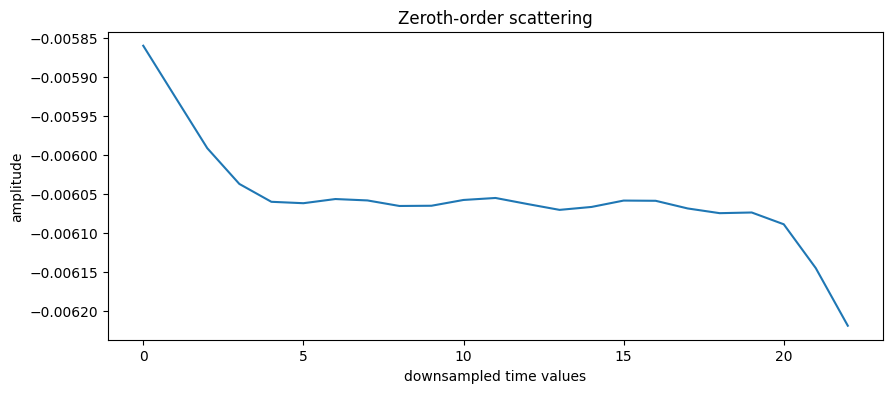

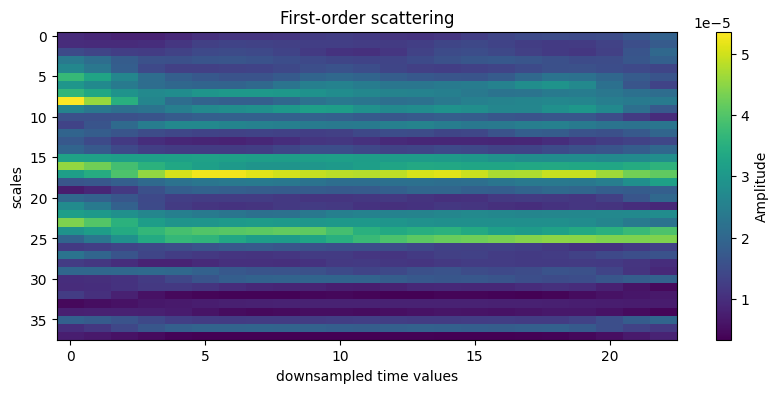

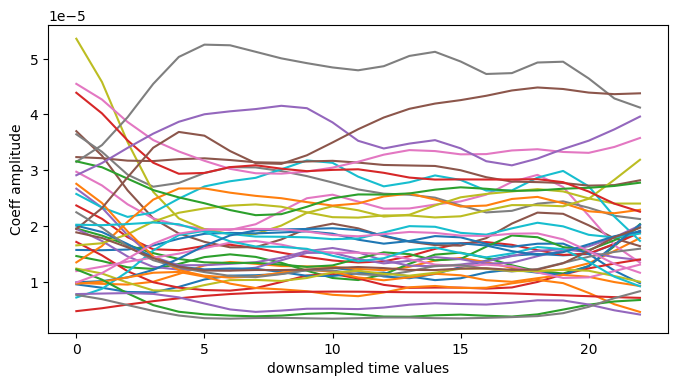

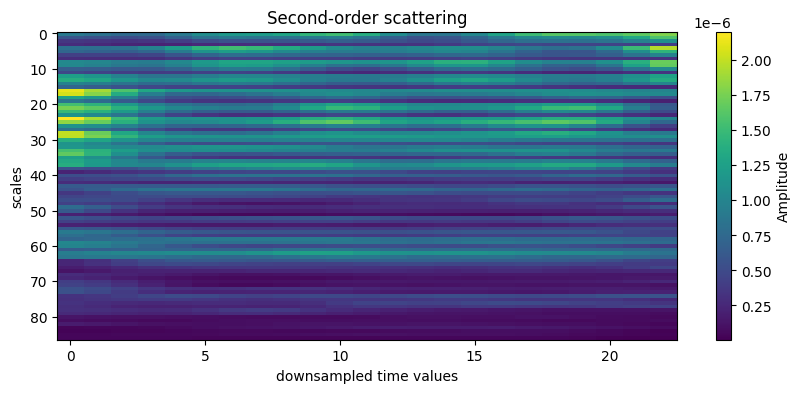

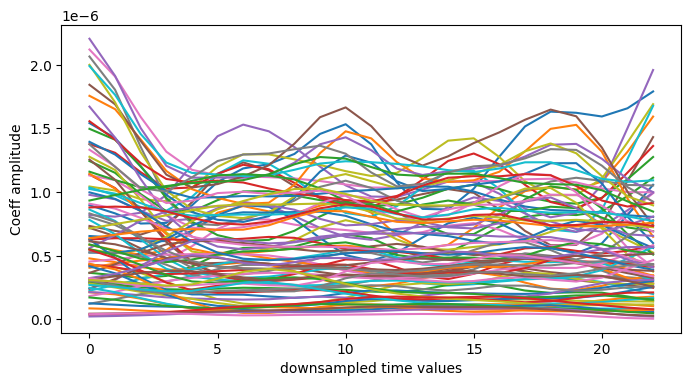

In [7]:
order0 = np.where(meta['order'] == 0)
order1 = np.where(meta['order'] == 1)
order2 = np.where(meta['order'] == 2)


plt.figure(figsize=(10, 4))
plt.plot(Sx[order0][0])
plt.title('Zeroth-order scattering')
plt.xlabel('downsampled time values')
plt.ylabel('amplitude')


plt.figure(figsize=(10, 4))
plt.imshow(Sx[order1], aspect='auto')
plt.title('First-order scattering')
plt.colorbar(label='Amplitude')
plt.xlabel('downsampled time values')
plt.ylabel('scales')


df = pd.DataFrame(Sx[order1].T)
df.plot(legend=False, figsize=(8, 4))
plt.ylabel("Coeff amplitude")
plt.xlabel("downsampled time values")

plt.figure(figsize=(10, 4))
plt.imshow(Sx[order2], aspect='auto')
plt.title('Second-order scattering')
plt.colorbar(label='Amplitude')
plt.xlabel('downsampled time values')
plt.ylabel('scales')


df = pd.DataFrame(Sx[order2].T)
df.plot(legend=False, figsize=(8, 4))
plt.ylabel("Coeff amplitude")
plt.xlabel("downsampled time values")


# https://github.com/borisbolliet/ScatteringTransformTutorials/tree/main
     

In [8]:

total_scales_order1, time_segm = order_1_coeffs.shape  
total_scales_order2, time_segm = order_2_coeffs.shape  

scales_order1 = list(range(1, total_scales_order1, 4))
scales_order2 = list(range(1, total_scales_order2, 4))



In [9]:
fs = 500
scales_order1_ = total_scales_order1 + 1  

xi_order1 = meta['xi'][:scales_order1_, 0]  
xi_order2 = meta['xi'][scales_order1_:, 0]  

xi_order1 = xi_order1[~np.isnan(xi_order1)]  
xi_order2 = xi_order2[~np.isnan(xi_order2)]  

# Multiplicar las freq centrales de los wavelets por (fs / 2) para obtener frecuencias en Hz
freq_order1 = xi_order1 * (fs / 2)
freq_order2 = xi_order2 * (fs / 2)

freq_order1= np.round(freq_order1[::4], 2)   # Seleccionar cada 4 valores de las frecuencias
freq_order2 = np.round(freq_order2[::4], 2) 

print(scales_order1)
print('Number of scales ORDER 1: ', total_scales_order1)
df_1 = pd.DataFrame({
    'Scale': scales_order1,  # Escalas del primer orden
    'Frequency (Hz)': freq_order1  # Frecuencias calculadas
})
print(df_1)

print()

print('Number of scales ORDER 2: ', total_scales_order2)
df_2 = pd.DataFrame({
    'Scale': scales_order2,  # Escalas del sge orden
    'Frequency (Hz)': freq_order2  # Frecuencias calculadas
})
print(df_2)


[1, 5, 9, 13, 17, 21, 25, 29, 33, 37]
Number of scales ORDER 1:  38
   Scale  Frequency (Hz)
0      1          108.85
1      5           76.97
2      9           54.42
3     13           38.48
4     17           27.21
5     21           19.24
6     25           13.61
7     29            9.62
8     33            6.07
9     37            2.02

Number of scales ORDER 2:  87
    Scale  Frequency (Hz)
0       1          108.85
1       5           99.81
2       9           91.53
3      13           83.93
4      17           76.97
5      21           70.58
6      25           64.72
7      29           59.35
8      33           54.42
9      37           49.91
10     41           45.76
11     45           41.97
12     49           38.48
13     53           32.36
14     57           29.67
15     61           27.21
16     65           22.88
17     69           19.24
18     73           16.18
19     77           13.61
20     81           11.44
21     85            8.09


#### 
#### **INFO DE LOS KEYS QUE SALEN EN LA METADATA:**

* order: Indica el orden del coeficiente de dispersión. Puede ser 0, 1 o 2, donde:
- 0: Coeficiente de orden cero (energía total de la señal).
- 1: Coeficiente de primer orden (captura variaciones locales).
- 2: Coeficiente de segundo orden (captura interacciones entre diferentes escalas).

* xi: Frecuencia central del filtro wavelet utilizado para calcular el coeficiente. Representa la frecuencia a la que el filtro wavelet es más sensible.

* sigma: Ancho del filtro wavelet en el dominio de la frecuencia. Indica la selectividad en frecuencia del filtro.

* j: Escala del filtro wavelet. Representa la dilatación del filtro wavelet y está relacionada con la resolución temporal y frecuencial.

* n: Índice del filtro wavelet dentro de una escala específica. Se utiliza para diferenciar entre diferentes filtros dentro de la misma escala.

* key: Clave única que identifica el coeficiente de dispersión. Puede ser utilizada para acceder a los coeficientes específicos en el conjunto de resultados.

23
only 1 coeff of order 0


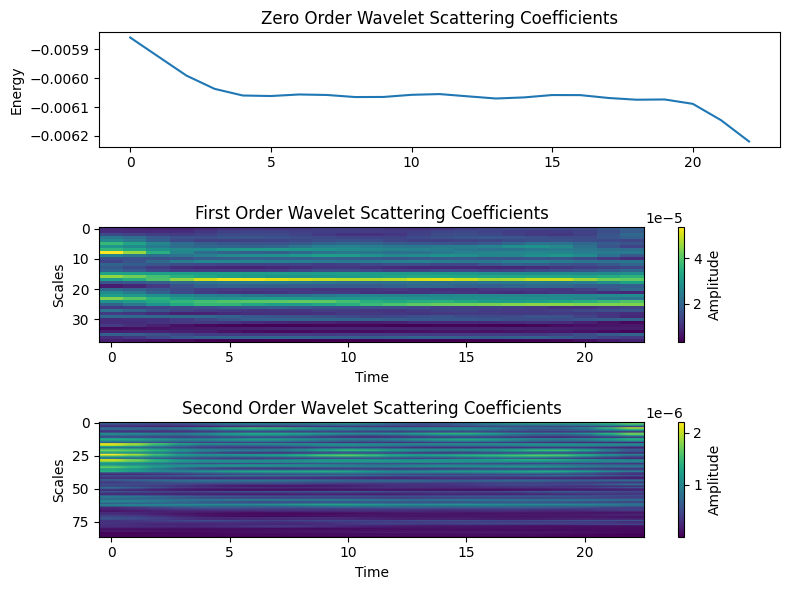

In [8]:
# PLOTTING SCATTERING COEFFS DEPENDING ON THE ORDER

plt.figure(figsize=(8, 6))

# Coeffs order 0
plt.subplot(3, 1, 1)
print(len(order_0_coeffs[0]))
#plt.plot(order_0_coeffs.T)

if len(order_0_coeffs) > 1:
    print("more than 1 coeff", len(order_0_coeffs))
    plt.plot(order_0_coeffs[0])
    

else:
    print("only 1 coeff of order 0")
    plt.plot(order_0_coeffs[0])

plt.title('Zero Order Wavelet Scattering Coefficients')
plt.ylabel('Energy')


# Coeffs order 1
plt.subplot(3, 1, 2)
plt.imshow(order_1_coeffs, aspect='auto')
plt.colorbar(label='Amplitude')
plt.title('First Order Wavelet Scattering Coefficients')
plt.xlabel('Time')
plt.ylabel('Scales')

# Coeffs order 2
plt.subplot(3, 1, 3)
plt.imshow(order_2_coeffs, aspect='auto')
plt.colorbar(label='Amplitude')
plt.title('Second Order Wavelet Scattering Coefficients')
plt.xlabel('Time')
plt.ylabel('Scales')

plt.tight_layout()
plt.show()

1500
(126, 23)


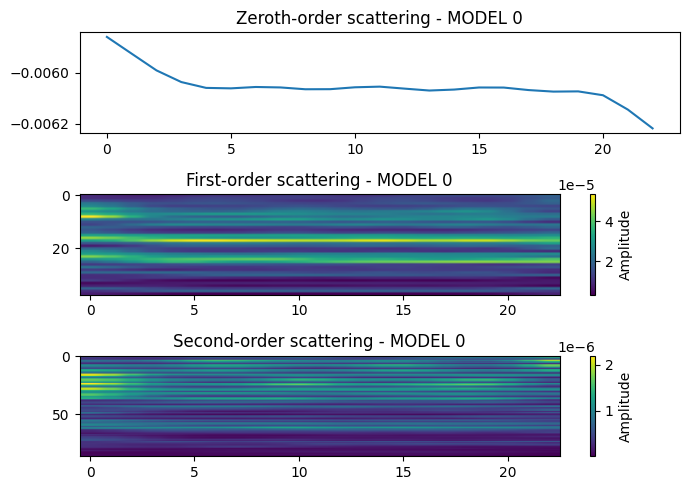

2499
(126, 39)


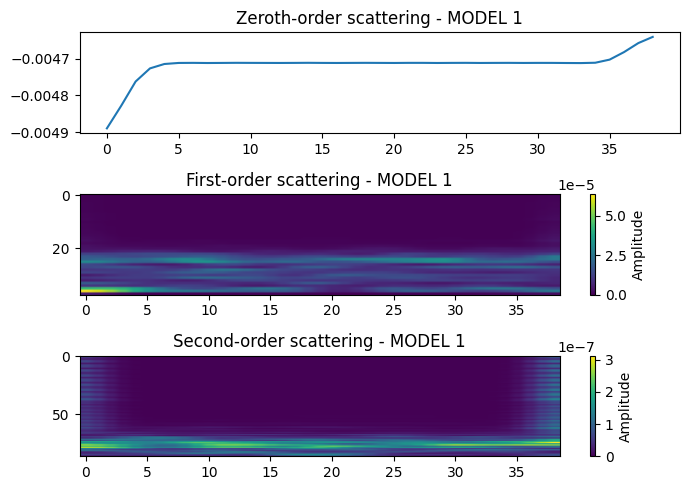

1301
(126, 21)


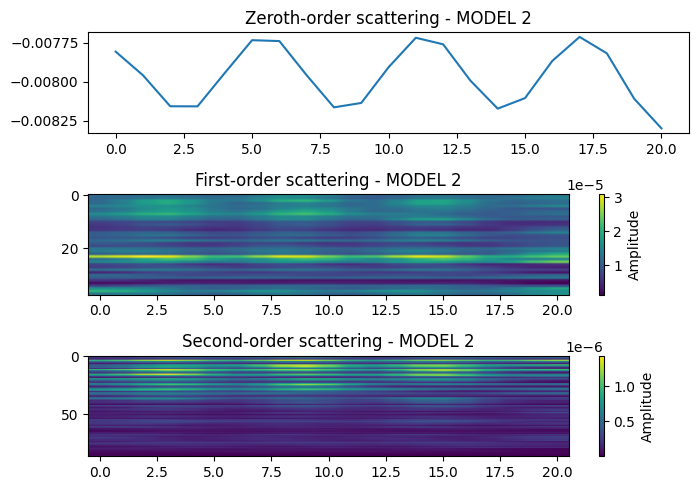

1500
(126, 23)


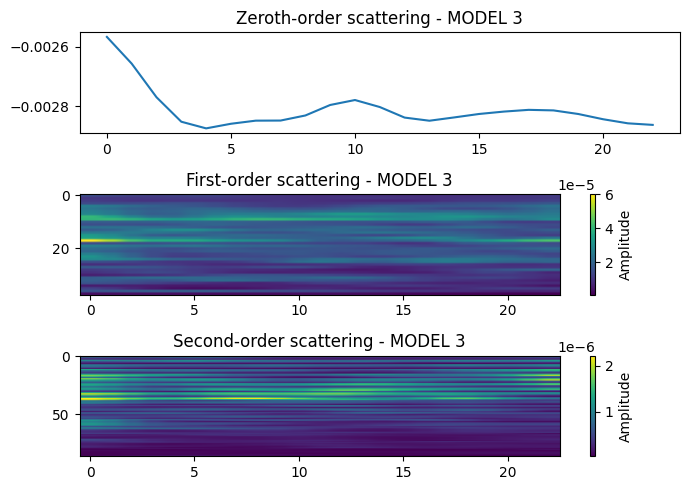

4000
(126, 63)


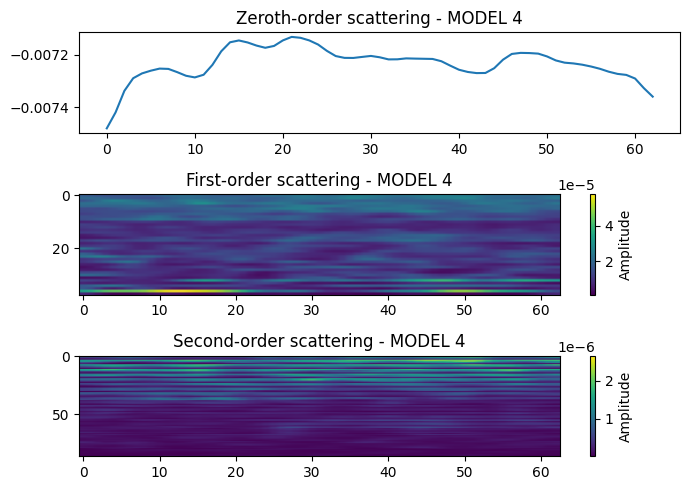

4000
(126, 63)


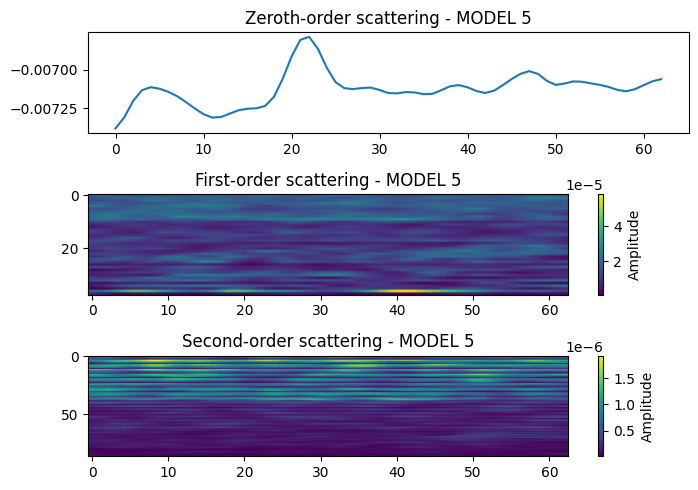

2000
(126, 31)


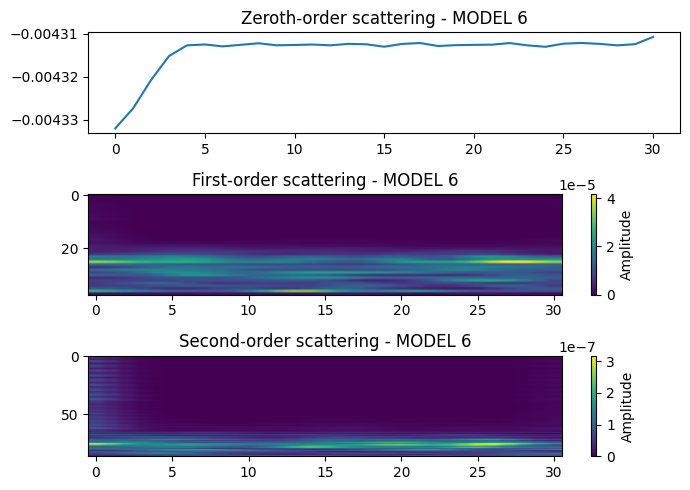

2000
(126, 31)


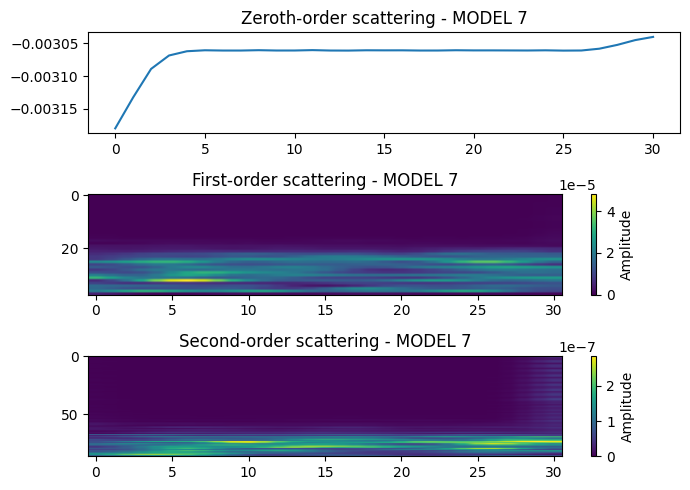

2001
(126, 31)


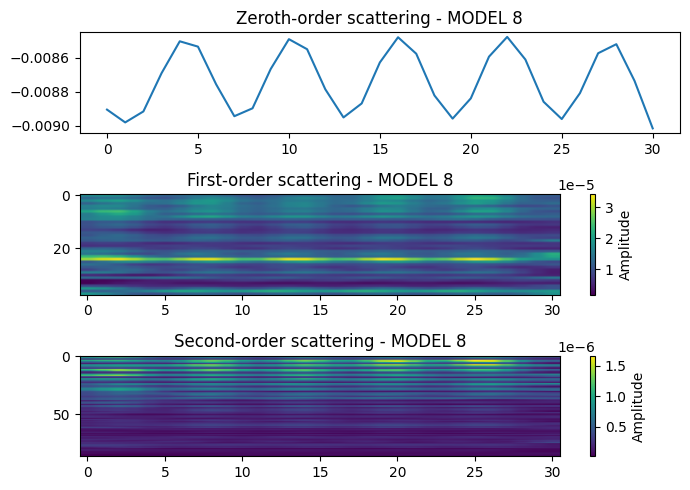

2499
(126, 39)


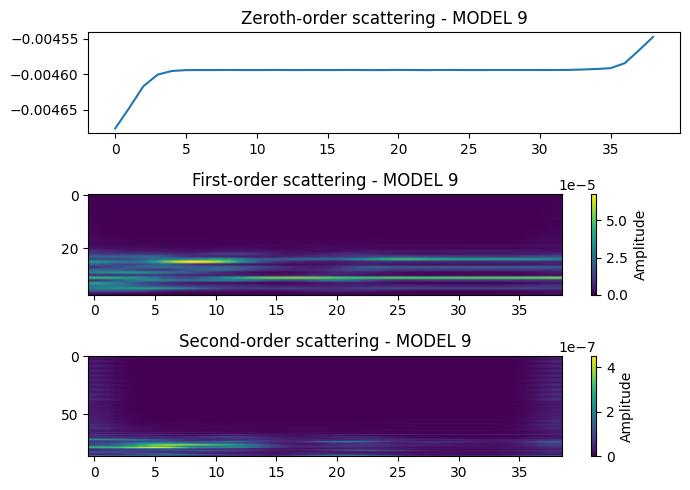

2499
(126, 39)


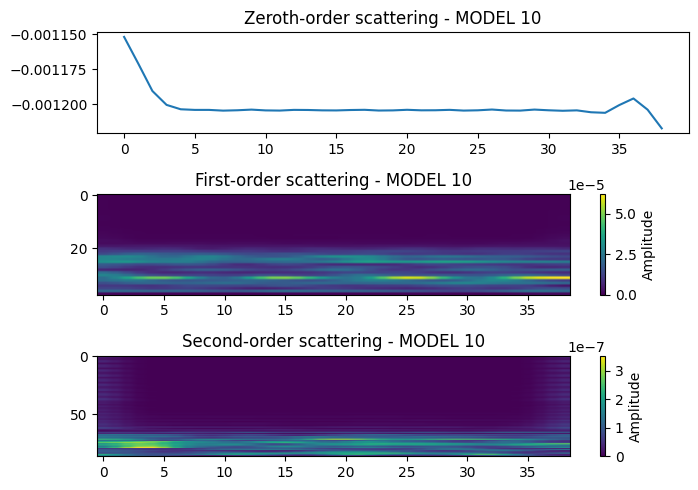

4501
(126, 71)


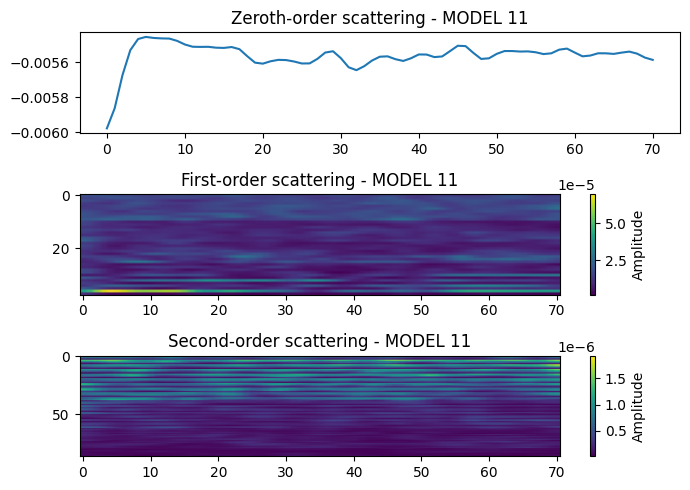

In [9]:
import numpy as np
ws_coeffs_all_models = []
ws_coeffs_order0 = []
ws_coeffs_order1 = []
ws_coeffs_order2 = []


for i in range(len(bsps_64_all_models)):

    signal = bsps_64_all_models[i][0, :]
    T = len(signal)
    print(T)
    scattering = Scattering1D(J=6, shape=T, Q=8) #calculate wavelet scattering coeffs

    # Perform the scattering transform
    Sx = scattering(signal)
    meta = scattering.meta()
    print(Sx.shape)
    ws_coeffs_all_models.append(Sx)

    #print('order of coeffs', meta['order'])  # coeff order

    order_0 = np.where(meta['order'] == 0)  # coeffs order 0
    #print("Coeffs order 0:", order_0.shape)
    ws_coeffs_order0.append(order_0)

    order_1 = np.where(meta['order'] == 1) # coeffs order 1
    #print("Coeffs order 1:", order_1.shape)
    ws_coeffs_order1.append(order_1)

    order_2 = np.where(meta['order'] == 2) # coeffs order 2
    #print("Coeffs order 2:", order_2.shape)
    ws_coeffs_order2.append(order_2)

    plt.figure(figsize=(7, 5))
    plt.subplot(3, 1, 1)
    plt.plot(Sx[order_0][0])
    plt.title(f'Zeroth-order scattering - MODEL {i}')

    plt.subplot(3, 1, 2)
    plt.imshow(Sx[order_1], aspect='auto')
    plt.title(f'First-order scattering - MODEL {i}')
    plt.colorbar(label='Amplitude')

    plt.subplot(3, 1, 3)
    plt.imshow(Sx[order_2], aspect='auto')
    plt.title(f'Second-order scattering - MODEL {i}')
    plt.colorbar(label='Amplitude')
    
    plt.tight_layout()

    plt.show()

#### ¿Qué significan las ESCALAS (eje Y) en Wavelet Scattering?
En lugar de frecuencia (como en un espectrograma de Fourier), el eje Y en Wavelet Scattering representa las escalas de las wavelets.
Cada escala está asociada a un nivel de dilatación de la wavelet, lo que equivale a diferentes bandas de frecuencia:

Escalas bajas (índices pequeños en el eje Y) → Capturan detalles de alta frecuencia (cambios rápidos en la señal).
Escalas altas (índices grandes en el eje Y) → Capturan tendencias de baja frecuencia (estructuras globales más lentas).
Básicamente, es como si las escalas fueran "filtros" que descomponen la señal en diferentes niveles de detalle, análogos a bandas de frecuencia pero en términos de wavelets.

FILTROS DE FOURIER VS FILTROS WAVELET



Longitud nueva tras interpolación: 2048


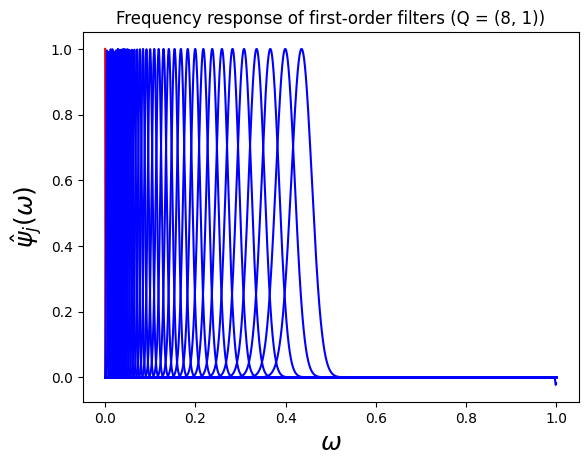

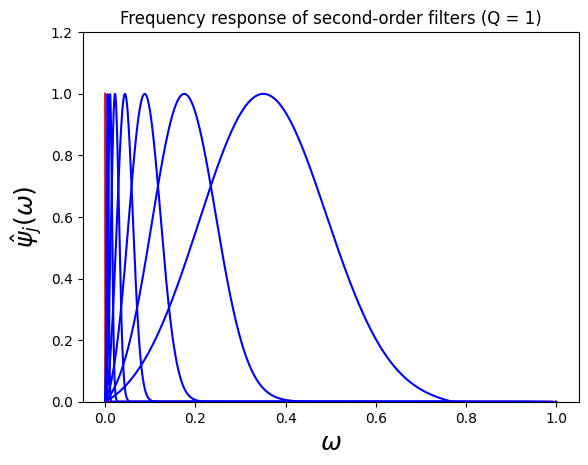

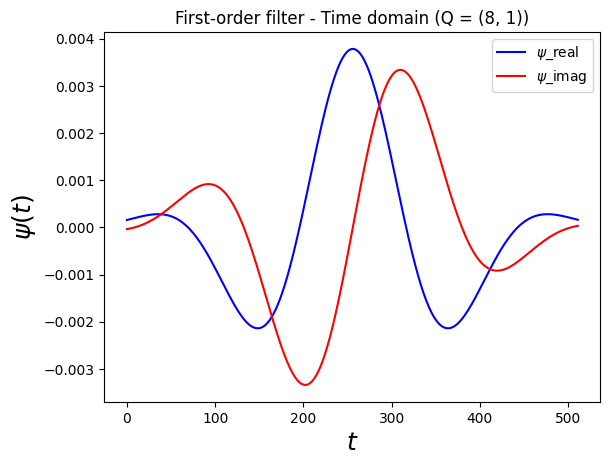

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from kymatio import Scattering1D
from kymatio.scattering1d.filter_bank import scattering_filter_factory

from scipy.signal import resample
signal = bsps_64_all_models[0][0, :]

new_length = 2048  # O puedes probar con 1024
resampled_signal = resample(signal, new_length)

print(f"Longitud nueva tras interpolación: {len(resampled_signal)}")

fs = 500

J = 6
Q = (8, 1)
T = len(resampled_signal)
phi_f, psi1_f, psi2_f = scattering_filter_factory(T, J, Q, T)

#Plot the frequency response of the filters
plt.figure()
plt.rcParams.update({"text.usetex": False})
plt.plot(np.arange(T)/T, phi_f['levels'][0], 'r')

for psi_f in psi1_f:
    plt.plot(np.arange(T)/T, psi_f['levels'][0], 'b')

#plt.xlim(0, 0.5)

plt.xlabel(r'$\omega$', fontsize=18)
plt.ylabel(r'$\hat\psi_j(\omega)$', fontsize=18)
plt.title('Frequency response of first-order filters (Q = {})'.format(Q),
          fontsize=12)

# same plot for the second-order filters. 
# Note that since here Q = 1, we obtain wavelets that have higher frequency bandwidth.

plt.figure()
plt.rcParams.update({"text.usetex": False})
plt.plot(np.arange(T)/T, phi_f['levels'][0], 'r')
for psi_f in psi2_f:
    plt.plot(np.arange(T)/T, psi_f['levels'][0], 'b')
#plt.xlim(0, 0.5)
plt.ylim(0, 1.2)
plt.xlabel(r'$\omega$', fontsize=18)
plt.ylabel(r'$\hat\psi_j(\omega)$', fontsize=18)
plt.title('Frequency response of second-order filters (Q = 1)', fontsize=12)


# Plot the filter in time domain
plt.figure()
plt.rcParams.update({"text.usetex": False})

psi_time = np.fft.ifft(psi1_f[-1]['levels'][0])
psi_real = np.real(psi_time)
psi_imag = np.imag(psi_time)
plt.plot(np.concatenate((psi_real[-2**8:],psi_real[:2**8])),'b')
plt.plot(np.concatenate((psi_imag[-2**8:],psi_imag[:2**8])),'r')


plt.xlabel(r'$t$', fontsize=18)
plt.ylabel(r'$\psi(t)$', fontsize=18)
plt.title('First-order filter - Time domain (Q = {})'.format(Q), fontsize=12)
plt.legend(["$\psi$_real","$\psi$_imag"])

plt.show()

In [19]:

from kymatio.scattering1d.filter_bank import scattering_filter_factory
T = 8192 # 2**13
J = 9
Q = (16,8)

phi_f, psi1_f, psi2_f = scattering_filter_factory(T, J, Q, T)
print(len(phi_f), len(psi1_f), len(psi2_f))

phi_f.keys()


4 111 62


dict_keys(['levels', 'xi', 'sigma', 'j'])

In [20]:

print(psi1_f[0].keys())

print(phi_f['xi'])

dict_keys(['levels', 'xi', 'sigma', 'j'])
0


phi_f['levels'][0] corresponds to the lowpass filter at resolution T, while phi_f['levels'][1] corresponds to the filter at resolution T/2, and so on.

While phi_f only contains a single filter (at different resolutions), the psi1_f and psi2_f outputs are lists of filters, one for each wavelet bandpass filter in the filter bank.

In [21]:

t = np.arange(T)/T
print(len(t))

phi_f['levels'][0].shape,phi_f['levels'][1].shape,phi_f['levels'][2].shape,phi_f['levels'][3].shape,phi_f['levels'][4].shape,phi_f['levels'][5].shape


8192


((8192,), (4096,), (2048,), (1024,), (512,), (256,))

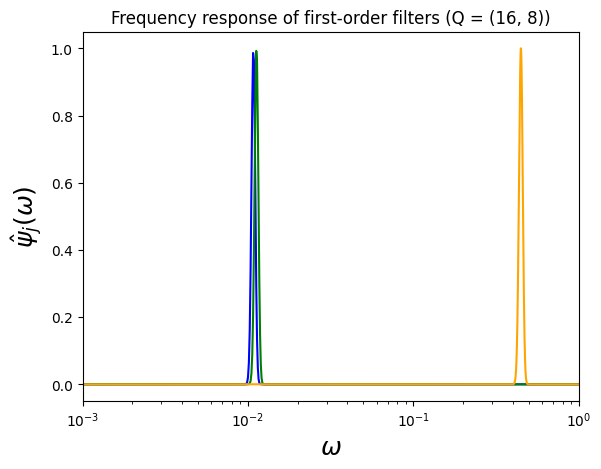

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# plt.figure()
# plt.rcParams.update({"text.usetex": True})


# for psi_f in psi1_f:
psi_f = psi1_f[87]
plt.plot(t, psi_f['levels'][0], 'b')
psi_f = psi1_f[86]
plt.plot(t, psi_f['levels'][0], 'g')

psi_f = psi1_f[1]
plt.plot(t, psi_f['levels'][0], 'orange')

plt.xlim(0.001, 1)

plt.xlabel(r'$\omega$', fontsize=18)
plt.ylabel(r'$\hat\psi_j(\omega)$', fontsize=18)
plt.title('Frequency response of first-order filters (Q = {})'.format(Q),
          fontsize=12)
plt.xscale('log')

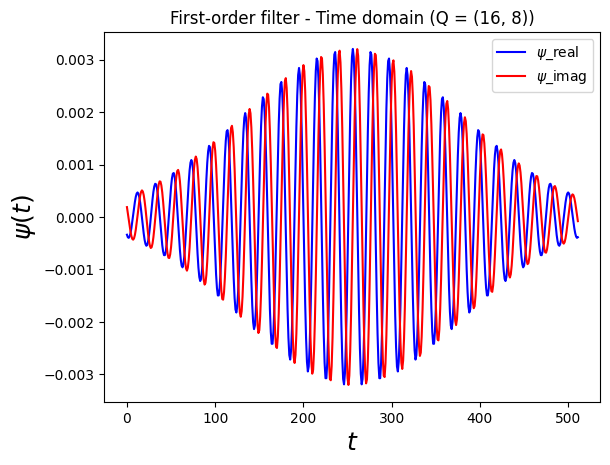

In [23]:
plt.figure()

psi_time = np.fft.ifft(psi1_f[52]['levels'][0])  # Transformada inversa
psi_real = np.real(psi_time)  # Parte real
psi_imag = np.imag(psi_time)  # Parte imaginaria

plt.plot(np.concatenate((psi_real[-2**8:],psi_real[:2**8])),'b') # Real
plt.plot(np.concatenate((psi_imag[-2**8:],psi_imag[:2**8])),'r') # Imaginaria
plt.xlabel(r'$t$', fontsize=18)
plt.ylabel(r'$\psi(t)$', fontsize=18)
plt.title('First-order filter - Time domain (Q = {})'.format(Q), fontsize=12)
plt.legend(["$\psi$_real","$\psi$_imag"])
plt.show()

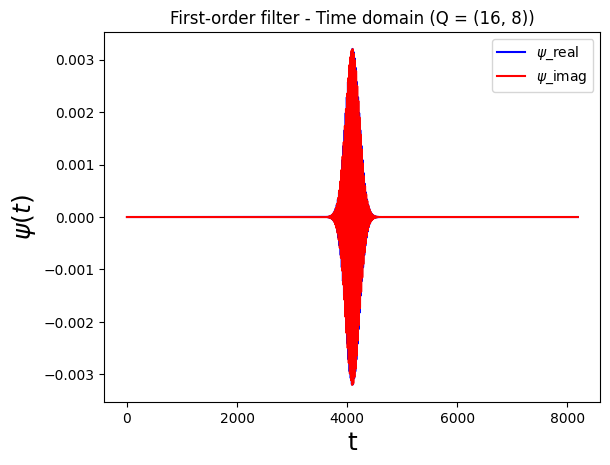

In [24]:
plt.figure()

psi_time = np.fft.ifft(psi1_f[52]['levels'][0])
psi_real = np.real(psi_time)
psi_imag = np.imag(psi_time)
plt.plot(np.concatenate((psi_real[-2**12:],psi_real[:2**12])),'b')
plt.plot(np.concatenate((psi_imag[-2**12:],psi_imag[:2**12])),'r')



plt.xlabel(r't', fontsize=18)
plt.ylabel(r'$\psi(t)$', fontsize=18)
plt.title('First-order filter - Time domain (Q = {})'.format(Q), fontsize=12)
plt.legend(["$\psi$_real","$\psi$_imag"])

plt.show()

In [25]:
len(np.concatenate((psi_real[-2**12:],psi_real[:2**12])))

# https://github.com/borisbolliet/ScatteringTransformTutorials/blob/main/learning_scattering_transforms_1d.ipynb

8192

In [26]:
# We need a small constant to add to the scattering coefficients before
# computing the logarithm. This prevents very large values when the scattering
# coefficients are very close to zero.
log_eps = 1e-6

# puede servir, web kymatio ex https://github.com/kymatio/kymatio/blob/main/examples/1d/classif_keras.py 

In [27]:
# To increase discriminability, we take the logarithm of the scattering
# coefficients (after adding a small constant to make sure nothing blows up
# when scattering coefficients are close to zero). This is known as the
# log-scattering transform.

#x = layers.Lambda(lambda x: tf.math.log(tf.abs(x) + log_eps))(x)

#https://www.kymat.io/gallery_1d/plot_synthetic.html 


# https://github.com/cyrusvahidi/scat1d-tutorial/blob/main/Kymatio%20Workshop%202022%3A%20Scattering1D%20Tutorial.ipynb

###
###
### **SCATTERING Y MODELOS DE CLASIFICACION**

In [10]:
bsps_64_all_models_s = bsps_64_all_models[8]
signal_s = bsps_64_all_models_s[0,:]-np.mean(bsps_64_all_models_s[0,:]) #PRIMER NODO

bsps_64_all_models_c = bsps_64_all_models[6]
signal_c = bsps_64_all_models_c[0,:]-np.mean(bsps_64_all_models_c[0,:])


In [11]:
import kymatio
from kymatio import Scattering1D

fs = 500 
J = 4
Q = (16,1)
signal_ss_cc = [bsps_64_all_models_s, bsps_64_all_models_c]
signals_name = ["Simple rhythm", "Complex AF rhythm"]

ws_coeffs_results_ss_cc = []
ws_coeffs_results_ss = []
ws_coeffs_results_cc = []

# Aplicar wavelet scattering a los todos los nodos de los 2 modelos (simple y complex)
for signal_list, signal_model in zip(signal_ss_cc, signals_name):
    print(f"\nModel {signal_model}")
    print("Samples of every node:", len(signal_list), "samples")
    for j in range(len(signal_list)):
        #print(f"Node {j} of {len(signal_list)}")
        signal = signal_list[j, :]  
        len_signal = len(signal)
        scattering = Scattering1D(J=J, shape=(len_signal,), Q=Q)
        Sx = scattering(signal)
        ws_coeffs_results_ss_cc.append(Sx)
        print(Sx.shape)
        if signal_model == "Simple rhythm":
            ws_coeffs_results_ss.append(Sx)
        else:
            ws_coeffs_results_cc.append(Sx)

print(len(ws_coeffs_results_ss))  


Model Simple rhythm
Samples of every node: 64 samples
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)

Model Complex AF rhythm
Samples of every node: 64 samples
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 125)
(74, 1

MODELO BASICO CLASSIFICATION --> RED CONVOLUCIONAL (3 capas, 16 filtros)
* INPUT: coefficients de scattering
* From SIMPLE model --> 64 nodes = 64 patients
* From COMPLEX model --> 64 nodes = 64 patients
* INPUT --> 128 signals scattering coefficients, to be classified into AF (1) or simple sinusoidal rhythm (0)

In [12]:
from sklearn.model_selection import train_test_split
X = np.array(ws_coeffs_results_ss_cc)  # (128, ?, ?)

# Creo etiquetas (0 = normal, 1 = AF)
#y = np.array([0] * len(ws_coeffs_results_ss) + [1] * len(ws_coeffs_results_cc))
y = np.concatenate([np.zeros(len(ws_coeffs_results_ss)), np.ones(len(ws_coeffs_results_cc))])
print(X.shape, y.shape)
print(y)

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


(128, 74, 125) (128,)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]


In [13]:
X_train = np.expand_dims(X_train, axis=-1)  
X_test = np.expand_dims(X_test, axis=-1)


print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(102, 74, 125, 1) (26, 74, 125, 1) (102,) (26,)


In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding="same", input_shape=X_train.shape[1:]),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding="same"),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')  # Dos clases: 0 y 1
])

# Compilar el modelo
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])  

# Resumen del modelo
model.summary()


2025-04-03 15:54:07.834277: I tensorflow/core/common_runtime/gpu/gpu_process_state.cc:236] Using CUDA malloc Async allocator for GPU: 0
2025-04-03 15:54:07.834549: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 443 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:16:00.0, compute capability: 8.9
2025-04-03 15:54:07.834797: I tensorflow/core/common_runtime/gpu/gpu_process_state.cc:236] Using CUDA malloc Async allocator for GPU: 1
2025-04-03 15:54:07.834998: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 21497 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:34:00.0, compute capability: 8.9


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 74, 125, 16)       160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 37, 62, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 37, 62, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 18, 31, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 18, 31, 64)        18496     
                                                                 
 flatten (Flatten)           (None, 35712)             0

In [15]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50


2025-04-03 15:54:10.640313: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-04-03 15:54:10.863048: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-04-03 15:54:11.338750: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-04-03 15:54:12.703238: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f8320781280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-03 15:54:12.703359: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-04-03 15:54:12.703370: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-04-03 15:54:12.719055: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_uti

6/6 [==============================] - 7s 196ms/step - loss: 0.6990 - accuracy: 0.4568 - val_loss: 0.6971 - val_accuracy: 0.3810
Epoch 2/50
6/6 [==============================] - 0s 26ms/step - loss: 0.6945 - accuracy: 0.4815 - val_loss: 0.6964 - val_accuracy: 0.3810
Epoch 3/50
6/6 [==============================] - 0s 29ms/step - loss: 0.6934 - accuracy: 0.5432 - val_loss: 0.6958 - val_accuracy: 0.3810
Epoch 4/50
6/6 [==============================] - 0s 25ms/step - loss: 0.6925 - accuracy: 0.5309 - val_loss: 0.6968 - val_accuracy: 0.3810
Epoch 5/50
6/6 [==============================] - 0s 28ms/step - loss: 0.6926 - accuracy: 0.5309 - val_loss: 0.6969 - val_accuracy: 0.3810
Epoch 6/50
6/6 [==============================] - 0s 25ms/step - loss: 0.6921 - accuracy: 0.5309 - val_loss: 0.6965 - val_accuracy: 0.3810
Epoch 7/50
6/6 [==============================] - 0s 21ms/step - loss: 0.6926 - accuracy: 0.5309 - val_loss: 0.6957 - val_accuracy: 0.3810
Epoch 8/50
6/6 [=====================

In [16]:
# Evaluación del modelo en el conjunto de test
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Precisión en test: {test_acc:.2%}")

1/1 [==============================] - 0s 156ms/step - loss: 0.6945 - accuracy: 0.5000
Precisión en test: 50.00%


In [17]:
# Selecciono señal de prueba
sample = X_test[0:1]  # Primera muestra de test
pred = model.predict(sample)
print("Probabilidades:", pred)

# Clase predicha (0 = normal, 1 = AF)
pred_class = np.argmax(pred)
print(f"Predicción: {'Normal' if pred_class == 0 else 'AF'}")

1/1 [==============================] - 0s 222ms/step
Probabilidades: [[0.45001718 0.54998285]]
Predicción: AF


In [18]:
real_class = y_test[0]  # La etiqueta real de la muestra seleccionada

# Comparar con la predicción
print(f"Etiqueta real: {'Normal' if real_class == 0 else 'AF'}")
if pred_class == real_class:
    print("Good Pred")
else:
    print("Wrong Pred")

Etiqueta real: AF
Good Pred


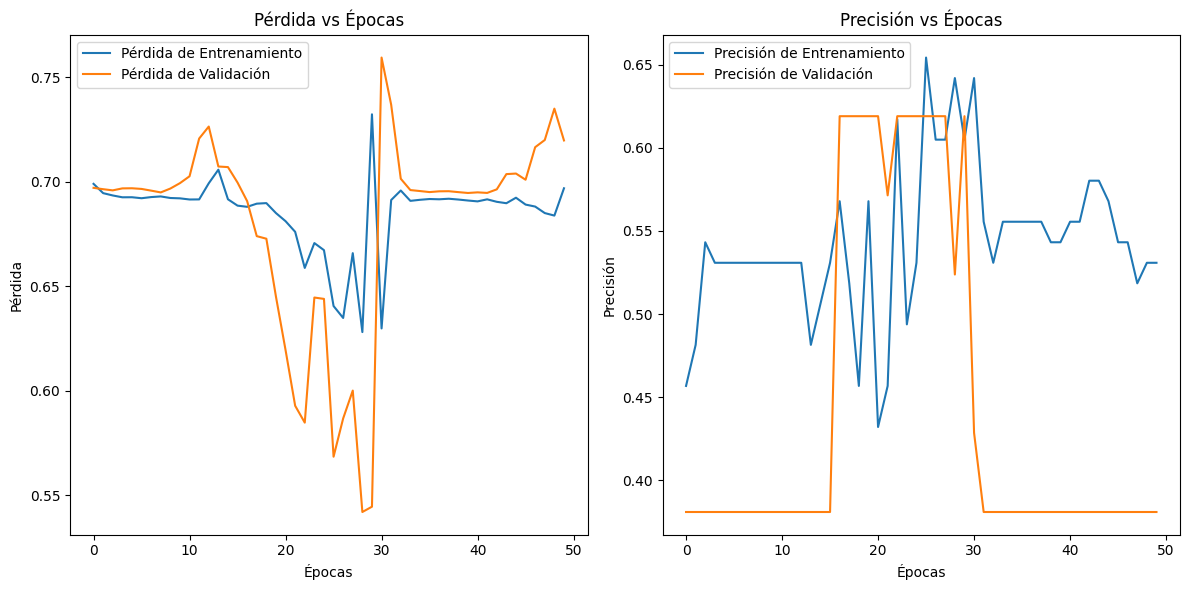

In [19]:

# Pérdida de entrenamiento y validación
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# Precisión de entrenamiento y validación
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()

- Si la pérdida de validación sigue aumentando después de varias épocas, mientras que la pérdida de entrenamiento sigue disminuyendo, eso puede indicar overfitting.
- Si la precisión de validación comienza a disminuir mientras que la precisión de entrenamiento sigue aumentando, también es una señal clara de overfitting.

In [20]:
#self.sinusal_groups
sinusal_groups = {
            "Simulation_01_200316_001_7", "Simulation_01_210209_001_002",
            "Simulation_01_210205_001_002", "Simulation_01_200428_001_001",
            "Simulation_01_200316_001_5", "Simulation_01_200428_001_005",
            "Simulation_01_200212_001_7", "Simulation_01_210119_001_001",
            "Simulation_01_210205_001_003", "Simulation_01_201223_001_002",
            "Simulation_01_200212_001_1", "Simulation_01_200428_001_003",
            "Simulation_01_200316_001_3", "Simulation_01_200316_001_4",
            "Sinusal_150629", "RA_RAA_141216", "Simulation_01_200428_001_002",
            "Simulation_01_210210_001_001", "Simulation_01_210208_001_002",
            "Simulation_01_200212_001_9", "Simulation_01_200316_001_1",
            "Simulation_01_200212_001_6", "Simulation_01_200212_001_5",
            "Simulation_01_210209_001_003", "Simulation_01_200316_001_9",
            "Simulation_01_210209_001_001", "Simulation_01_200428_001_006",
            "Simulation_01_200316_001_5",
        }
 
rotor_simple_groups = {
            "Simulation_01_200212_001_2", "Simulation_01_191001_001_002",
            "Simulation_01_190717_001_001", "Simulation_01_191001_001_007",
            "Simulation_01_200316_001_8", "Simulation_01_200428_001_004",
            "Simulation_01_200212_001_8", "Simulation_01_200212_001_10",
            "Simulation_01_191001_001_001", "Simulation_01_200428_001_007",
            "Simulation_01_200428_001_009", "Simulation_01_200428_001_010",
            "Simulation_01_200316_001_2", "Simulation_01_200316_001_6",
            "Simulation_01_200316_001_10", "Simulation_01_190502_001_003",
            "Simulation_01_190619_001_002", "Simulation_01_191001_001_005",
            "Simulation_01_200212_001_4", "Simulation_01_200212_001_10",
            "Simulation_01_200428_001_008", "Simulation_01_190502_001_005"
        }
 
rotor_complejo_groups = {
            "LA_RSPV_CAF_150115", "LA_RSPV_150113", "LA_PLAW_140612",
            "LA_LSPV_150203", "LA_LSPV_150113", "RA_RAFW_140807",
            "RA_RAA_141230", "TwoRotors_181219", "LA_PLAW_140711_arm",
            "RA_RAFW_SAF_140730", "LA_RIPV_150121", "LA_LIPV_150119"
        }
 

In [21]:
# ALMACENAR LOS SCATTERING COEFFS EN TENSORES --> EN ESTE CASO CADA SEÑAL TIENE 4 TENSORES DE 16 NODOS

fs = 500  
J = 4  
Q = (16,1)  
signal_ss_cc = [bsps_64_all_models_s, bsps_64_all_models_c]  
signals_name = ["Simple rhythm", "Complex AF rhythm"]

ws_coeffs_results_ss_cc_tensors = []
ws_coeffs_results_ss_tensors = []
ws_coeffs_results_cc_tensors = []

# Aplicar wavelet scattering a todos los nodos de los 2 modelos
for signal_list, signal_model in zip(signal_ss_cc, signals_name):
    print(f"\nModel {signal_model}")
    print("Samples of every node:", len(signal_list), "samples")
    
    scattering_results = []  # Para almacenar los coeficientes de todos los nodos

    for j in range(len(signal_list)):
        signal = signal_list[j, :]
        len_signal = len(signal)
        scattering = Scattering1D(J=J, shape=(len_signal,), Q=Q)
        Sx = scattering(signal)
        scattering_results.append(Sx)  # Guardamos el scattering de cada nodo
    
    # Convertir la lista en un array de NumPy
    scattering_array = np.array(scattering_results)  # (64 nodos, num_coeffs)
    
    # Dividir en bloques de nodos (por ejemplo, en grupos de 16 nodos)
    num_nodos_por_tensor = 16
    scattering_array = scattering_array.reshape(4, num_nodos_por_tensor, *scattering_array.shape[1:])  # (4 bloques, 16 nodos, num_coeffs)
    
    # Guardar en la lista correspondiente
    ws_coeffs_results_ss_cc_tensors.append(scattering_array)
    if signal_model == "Simple rhythm":
        ws_coeffs_results_ss_tensors.append(scattering_array)
    else:
        ws_coeffs_results_cc_tensors.append(scattering_array)

print(f"Tamaño de cada tensor de scattering: {ws_coeffs_results_ss_cc_tensors[0].shape}")
print(len(ws_coeffs_results_ss_tensors[0]))  # Número de tensores para el modelo simple
print(len(ws_coeffs_results_cc_tensors[0][3]))  # Número de tensores para el modelo complejo
print(len(ws_coeffs_results_ss_cc_tensors[0]))


Model Simple rhythm
Samples of every node: 64 samples

Model Complex AF rhythm
Samples of every node: 64 samples
Tamaño de cada tensor de scattering: (4, 16, 74, 125)
4
16
4


##### **MODELO BASICO CLASSIFICATION CON TENSORES** --> RED CONVOLUCIONAL (3 capas, 16 filtros)
* INPUT: tensores coefficients de scattering de 16 nodos 
* From SIMPLE model --> 4 tensors of 16 nodes each one (1 tensor = 1 patient)
* From COMPLEX model --> 4 tensors of 16 nodes each one (1 tensor = 1 patient)
* INPUT --> 8 tensors with 16 node's scattering coefficients (size 74x125), to be classified into AF (1) or simple sinusoidal rhythm (0)

In [22]:
X = np.concatenate(ws_coeffs_results_ss_cc_tensors, axis=0)  # (N, ?, ?)

# Crear etiquetas (0 = normal, 1 = AF)
y_ss = np.zeros(X.shape[0] // 2)  # Mitad de los datos son normales
y_cc = np.ones(X.shape[0] // 2)   # Mitad de los datos son AF
y = np.concatenate([y_ss, y_cc])

print("X shape:", X.shape)  # Verificar la dimensión de entrada
print("y shape:", y.shape)  # Verificar las etiquetas
print("y:", y[:20])  # Revisar algunas etiquetas

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape, "y_test shape:", y_test.shape)

X shape: (8, 16, 74, 125)
y shape: (8,)
y: [0. 0. 0. 0. 1. 1. 1. 1.]
X_train shape: (6, 16, 74, 125) X_test shape: (2, 16, 74, 125)
y_train shape: (6,) y_test shape: (2,)


In [23]:
print("Shape of X_train before transposition:", X_train.shape)
print("Shape of X_test before transposition:", X_test.shape)

X_train = np.transpose(X_train, (0, 2, 3, 1))  # (samples, height, width, channels)
X_test = np.transpose(X_test, (0, 2, 3, 1))    # (samples, height, width, channels)

print("X_train shape:", X_train.shape)  # (6, 74, 125, 16)
print("X_test shape:", X_test.shape)    # (2, 74, 125, 16)

Shape of X_train before transposition: (6, 16, 74, 125)
Shape of X_test before transposition: (2, 16, 74, 125)
X_train shape: (6, 74, 125, 16)
X_test shape: (2, 74, 125, 16)


In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding="same", input_shape=X_train.shape[1:]),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding="same"),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')  # Dos clases: 0 y 1
])

# Compilar el modelo
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])  

# Resumen del modelo
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 74, 125, 16)       2320      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 37, 62, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 37, 62, 32)        4640      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 18, 31, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 18, 31, 64)        18496     
                                                                 
 flatten_1 (Flatten)         (None, 35712)            

In [25]:
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_split=0.2)

Epoch 1/30
1/1 [==============================] - 4s 4s/step - loss: 0.6932 - accuracy: 0.2500 - val_loss: 0.6979 - val_accuracy: 0.0000e+00
Epoch 2/30
1/1 [==============================] - 0s 98ms/step - loss: 0.6918 - accuracy: 0.7500 - val_loss: 0.7231 - val_accuracy: 0.0000e+00
Epoch 3/30
1/1 [==============================] - 0s 101ms/step - loss: 0.6886 - accuracy: 0.5000 - val_loss: 0.7756 - val_accuracy: 0.0000e+00
Epoch 4/30
1/1 [==============================] - 0s 86ms/step - loss: 0.6315 - accuracy: 0.7500 - val_loss: 0.8927 - val_accuracy: 0.0000e+00
Epoch 5/30
1/1 [==============================] - 0s 73ms/step - loss: 0.6674 - accuracy: 0.7500 - val_loss: 1.0417 - val_accuracy: 0.0000e+00
Epoch 6/30
1/1 [==============================] - 0s 83ms/step - loss: 0.5976 - accuracy: 0.7500 - val_loss: 1.2411 - val_accuracy: 0.0000e+00
Epoch 7/30
1/1 [==============================] - 0s 89ms/step - loss: 0.6340 - accuracy: 0.7500 - val_loss: 1.4262 - val_accuracy: 0.0000e+00


In [26]:
# Evaluación del modelo en el conjunto de test
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Precisión en test: {test_acc:.2%}")

1/1 [==============================] - 0s 40ms/step - loss: 0.8318 - accuracy: 0.5000
Precisión en test: 50.00%


In [27]:
# Selecciono señal de prueba
sample = X_test[0:1]  # Primera muestra de test
pred = model.predict(sample)
print("Probabilidades:", pred)

# Clase predicha (0 = normal, 1 = AF)
pred_class = np.argmax(pred)
print(f"Predicción: {'Normal' if pred_class == 0 else 'AF'}")

1/1 [==============================] - 0s 209ms/step
Probabilidades: [[0.25355345 0.74644655]]
Predicción: AF


In [28]:
real_class = y_test[0]  # La etiqueta real de la muestra seleccionada

# Comparar con la predicción
print(f"Etiqueta real: {'Normal' if real_class == 0 else 'AF'}")
if pred_class == real_class:
    print("Good Pred")
else:
    print("Wrong Pred")

Etiqueta real: Normal
Wrong Pred


In [ ]:
filtered_models = []  # Lista para almacenar los modelos procesados

for model in bsps_64_all_models:
    new_model = []  # Lista para almacenar los nodos filtrados y recortados
    
    for node in model:
        original_length = len(node)  # Longitud original del nodo
        print(f"Antes: Node con longitud {original_length}")

        # Descartar los nodos menores de 2000 samples
        if original_length < 2000:
            print("Descartado: longitud menor a 2000")
            continue  # No agregar este nodo a new_model

        # Recortar nodos entre 2001 y 2500 samples a 2000
        if 2001 <= original_length <= 2500:
            node = node[:2000]

        # Recortar nodos entre 4001 y 4501 samples a 4000
        elif 4001 <= original_length <= 4501:
            node = node[:4000]

        # Imprimir la longitud después del recorte
        print(f"Después: Node con longitud {len(node)}")

        # Agregar el nodo procesado a la lista del modelo
        new_model.append(node)

    # Solo agregar el modelo si aún tiene nodos después del filtrado
    if len(new_model) > 0:
        filtered_models.append(new_model)
    else:
        print("Modelo descartado porque todos sus nodos fueron eliminados.")

print(f"Número final de modelos: {len(bsps_64_all_models)}")  # Confirmar el número final de modelos


Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: Node con longitud 2000
Después: Node con longitud 2000
Antes: N